# RDF N-Triples Analysis Notebook using rdflib


# =========================

# 1. Setup

# =========================


In [1]:
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, SKOS, XSD
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Helper Functions


In [2]:
def parse_file_safe(graph, path):
    encodings = ["utf-8", "latin-1", "cp1252"]

    for enc in encodings:
        try:
            with open(path, "r", encoding=enc) as f:
                graph.parse(f, format="nt")
            print(f"Loaded {path} with {enc}")
            return
        except UnicodeDecodeError:
            continue

    print(f"Failed to parse {path}")

# =========================

# 2. Load N-Triples Files

# =========================


In [3]:
import os

data_dir = "data"
g = Graph()


for file in os.listdir(data_dir):
    if file.endswith(".ntriples"):
        path = os.path.join(data_dir, file)
        print(f"Loading {path}")
        parse_file_safe(g, path)

print(f"Total triples loaded: {len(g)}")

Loading data\OpenPermID-bulk-assetClass.ntriples
Loaded data\OpenPermID-bulk-assetClass.ntriples with utf-8
Loading data\OpenPermID-bulk-currency.ntriples
Loaded data\OpenPermID-bulk-currency.ntriples with utf-8
Loading data\OpenPermID-bulk-industry.ntriples
Loaded data\OpenPermID-bulk-industry.ntriples with utf-8
Loading data\OpenPermID-bulk-instrument.ntriples
Loaded data\OpenPermID-bulk-instrument.ntriples with utf-8
Loading data\OpenPermID-bulk-organization.ntriples
Loaded data\OpenPermID-bulk-organization.ntriples with latin-1
Loading data\OpenPermID-bulk-person.ntriples
Loaded data\OpenPermID-bulk-person.ntriples with utf-8
Loading data\OpenPermID-bulk-quote.ntriples
Loaded data\OpenPermID-bulk-quote.ntriples with utf-8
Total triples loaded: 1690132


# =========================

# 3. Inspect Basic Structure

# =========================


In [4]:
# Print first 10 triples
for i, (s, p, o) in enumerate(g):
    if i >= 10:
        break
    print(s, p, o)

https://permid.org/1-21513022674 http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://permid.org/ontology/financial/Instrument
https://permid.org/1-8590219038 http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://permid.org/ontology/financial/Instrument
https://permid.org/1-21598167117 http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://permid.org/ontology/financial/Instrument
https://permid.org/1-8589965026 http://permid.org/ontology/financial/hasAssetClass https://permid.org/1-300281
https://permid.org/1-21475290527 http://permid.org/ontology/financial/hasInstrumentStatus http://permid.org/ontology/financial/instrumentStatusInActive
https://permid.org/1-21475167133 http://permid.org/ontology/common/hasName VPU Deco Plzen Common Stock
https://permid.org/1-8591311810 http://permid.org/ontology/financial/hasAssetClass https://permid.org/1-300281
https://permid.org/1-8589966404 http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://permid.org/ontology/financial/Instrument
https://p

# =========================

# 4. Explore Unique Elements

# =========================


In [5]:
subjects = set()
predicates = set()
uri_predicates = set()
literal_predicates = set()
objects = set()
both = set()
count = 0
for s, p, o in g:
    subjects.add(s)
    predicates.add(p)
    objects.add(o)
    both.add(s)
    both.add(o)
    if isinstance(o, Literal):
        literal_predicates.add(p)
    else:
        uri_predicates.add(p)
    count += 1


print("Total Size:", count)
print("Unique subjects:", len(subjects))
print("Unique predicates:", len(predicates))
print("Unique objects:", len(objects))
print("Unique Both:", len(both))

Total Size: 1690132
Unique subjects: 255792
Unique predicates: 28
Unique objects: 849669
Unique Both: 1105349


In [6]:
print(uri_predicates)


{rdflib.term.URIRef('https://permid.org/ontology/financial/quotedOrganization'), rdflib.term.URIRef('http://permid.org/ontology/financial/hasInstrumentStatus'), rdflib.term.URIRef('https://permid.org/ontology/financial/isPartOf'), rdflib.term.URIRef('https://permid.org/ontology/financial/hasIndustrySector'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://permid.org/ontology/financial/employedBy'), rdflib.term.URIRef('http://permid.org/ontology/financial/isIssuedBy'), rdflib.term.URIRef('https://permid.org/ontology/financial/quoteCurrency'), rdflib.term.URIRef('https://permid.org/ontology/financial/hasIndustry'), rdflib.term.URIRef('http://permid.org/ontology/financial/hasAssetClass'), rdflib.term.URIRef('https://permid.org/ontology/financial/belongsToAssetClass'), rdflib.term.URIRef('http://permid.org/ontology/financial/hasPrimaryQuote')}


In [7]:
print(literal_predicates)

{rdflib.term.URIRef('https://permid.org/ontology/financial/lotSize'), rdflib.term.URIRef('https://permid.org/ontology/financial/organizationStatusCode'), rdflib.term.URIRef('https://permid.org/ontology/financial/hasRole'), rdflib.term.URIRef('https://permid.org/ontology/financial/issuingCountry'), rdflib.term.URIRef('https://permid.org/ontology/financial/currencySymbol'), rdflib.term.URIRef('https://permid.org/ontology/financial/isoCode'), rdflib.term.URIRef('https://permid.org/ontology/financial/isActive'), rdflib.term.URIRef('https://permid.org/ontology/financial/instrumentCount'), rdflib.term.URIRef('http://permid.org/ontology/common/hasPermId'), rdflib.term.URIRef('https://permid.org/ontology/financial/gender'), rdflib.term.URIRef('https://permid.org/ontology/financial/listedOn'), rdflib.term.URIRef('https://permid.org/ontology/financial/foundedYear'), rdflib.term.URIRef('http://permid.org/ontology/common/hasName'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#label'), 

In [8]:
from rdflib import Graph, URIRef
import csv


# Intersection
common_nodes = subjects.intersection(objects)

print(f"Common nodes count: {len(common_nodes)}")

# Second pass: filter triples
filtered_triples = []
for s, p, o in g:
    if isinstance(o, URIRef) and o in common_nodes:
        filtered_triples.append((s, p, o))

print(f"Filtered triples count: {len(filtered_triples)}")

# Save to CSV
with open("Balabizo.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["subject", "predicate", "object"])

    for s, p, o in filtered_triples:
        writer.writerow([str(s), str(p), str(o)])

# print(f"Saved to {output_csv}")

Common nodes count: 112
Filtered triples count: 283


Conclusion: Majority of subjects are not objects


# =========================

# 5. Convert to DataFrame

# =========================


In [9]:
data = [(str(s), str(p), str(o)) for s, p, o in g]
df = pd.DataFrame(data, columns=["subject", "predicate", "object"])

df.head()

# Predicate frequency
predicate_counts = df["predicate"].value_counts()
predicate_counts.head(10)

predicate
http://www.w3.org/1999/02/22-rdf-syntax-ns#type             255792
http://permid.org/ontology/common/hasName                   255680
http://permid.org/ontology/financial/isIssuedBy             255589
http://permid.org/ontology/common/hasPermId                 255577
http://permid.org/ontology/financial/hasAssetClass          254465
http://permid.org/ontology/financial/hasInstrumentStatus    219171
http://permid.org/ontology/financial/hasPrimaryQuote        192990
http://www.w3.org/2000/01/rdf-schema#label                     215
https://permid.org/ontology/financial/quotedOrganization        60
https://permid.org/ontology/financial/quoteCurrency             60
Name: count, dtype: int64

# =========================

# 6. Namespace Handling

# =========================


In [10]:
EX = Namespace("http://permid.org/")

# Bind namespace (useful for serialization)
g.bind("ex", EX)

# =========================

# 7. Filtering Triples

# =========================


In [11]:
# Example: get all labels
labels = []
for s, p, o in g.triples((None, RDFS.label, None)):
    labels.append((s, o))

print("Sample labels:")
print(labels[:10])

Sample labels:
[(rdflib.term.URIRef('https://permid.org/ac-Equity'), rdflib.term.Literal('Equity', lang='en')), (rdflib.term.URIRef('https://permid.org/at-CommonStock'), rdflib.term.Literal('CommonStock', lang='en')), (rdflib.term.URIRef('https://permid.org/at-PreferredStock'), rdflib.term.Literal('PreferredStock', lang='en')), (rdflib.term.URIRef('https://permid.org/at-ETF'), rdflib.term.Literal('ETF', lang='en')), (rdflib.term.URIRef('https://permid.org/at-ClosedEndFund'), rdflib.term.Literal('ClosedEndFund', lang='en')), (rdflib.term.URIRef('https://permid.org/ac-FixedIncome'), rdflib.term.Literal('FixedIncome', lang='en')), (rdflib.term.URIRef('https://permid.org/at-GovernmentBond'), rdflib.term.Literal('GovernmentBond', lang='en')), (rdflib.term.URIRef('https://permid.org/at-CorporateBond'), rdflib.term.Literal('CorporateBond', lang='en')), (rdflib.term.URIRef('https://permid.org/at-MunicipalBond'), rdflib.term.Literal('MunicipalBond', lang='en')), (rdflib.term.URIRef('https://per

# =========================

# 8. SPARQL Queries

# =========================


In [12]:
query = """
SELECT ?s ?label
WHERE {
    ?s <http://www.w3.org/2000/01/rdf-schema#label> ?label .
}
LIMIT 10
"""

for row in g.query(query):
    print(row)

# More complex query: hierarchical relations
query_hierarchy = """
SELECT ?child ?parent
WHERE {
    ?child <http://www.w3.org/2004/02/skos/core#broader> ?parent .
}
LIMIT 10
"""

for row in g.query(query_hierarchy):
    print(row)

(rdflib.term.URIRef('https://permid.org/ac-Equity'), rdflib.term.Literal('Equity', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-CommonStock'), rdflib.term.Literal('CommonStock', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-PreferredStock'), rdflib.term.Literal('PreferredStock', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-ETF'), rdflib.term.Literal('ETF', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-ClosedEndFund'), rdflib.term.Literal('ClosedEndFund', lang='en'))
(rdflib.term.URIRef('https://permid.org/ac-FixedIncome'), rdflib.term.Literal('FixedIncome', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-GovernmentBond'), rdflib.term.Literal('GovernmentBond', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-CorporateBond'), rdflib.term.Literal('CorporateBond', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-MunicipalBond'), rdflib.term.Literal('MunicipalBond', lang='en'))
(rdflib.term.URIRef('https://permid.org/at-ConvertibleBon

# =========================

# 9. Working with Literals

# =========================


In [13]:
for s, p, o in g:
    if isinstance(o, Literal):
        print("Value:", o)
        print("Datatype:", o.datatype)
        print("Python value:", o.toPython())
        break

Value: VPU Deco Plzen Common Stock
Datatype: http://www.w3.org/2001/XMLSchema#string
Python value: VPU Deco Plzen Common Stock


# =========================

# 10. Graph Navigation

# =========================


In [14]:
# Pick one subject
sample_subject = next(iter(subjects))

print("\nAll triples for one subject:")
for p, o in g.predicate_objects(subject=sample_subject):
    print(p, o)


All triples for one subject:
http://permid.org/ontology/common/hasPermId 21475300187
http://permid.org/ontology/financial/hasPrimaryQuote https://permid.org/1-21475300189
http://permid.org/ontology/common/hasName Randfontein Est Common Stock
http://permid.org/ontology/financial/hasInstrumentStatus http://permid.org/ontology/financial/instrumentStatusInActive
http://permid.org/ontology/financial/isIssuedBy https://permid.org/1-4295889095
http://permid.org/ontology/financial/hasAssetClass https://permid.org/1-300281
http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://permid.org/ontology/financial/Instrument


# =========================

# 11. Build NetworkX Graph

# =========================


NetworkX nodes: 618286
NetworkX edges: 1178290


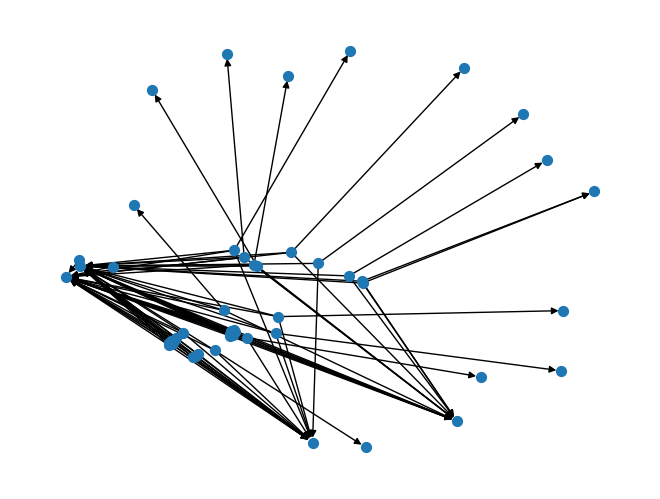

In [15]:
G_nx = nx.DiGraph()

for s, p, o in g:
    if isinstance(o, URIRef):
        G_nx.add_edge(str(s), str(o), label=str(p))

print("NetworkX nodes:", G_nx.number_of_nodes())
print("NetworkX edges:", G_nx.number_of_edges())

# Visualize small subgraph
sub_nodes = list(G_nx.nodes())[:50]
subgraph = G_nx.subgraph(sub_nodes)

plt.figure()
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, node_size=50, with_labels=False)
plt.show()

# =========================

# 12. Serialization

# =========================


In [16]:
# Save graph in different formats
g.serialize("output.ttl", format="turtle")
g.serialize("output.rdf", format="xml")

<Graph identifier=N139377f2314d4f43b3b0a28391cffdc5 (<class 'rdflib.graph.Graph'>)>

# =========================

# 13. Advanced: Reasoning (basic)

# =========================


In [17]:
# Example: find all broader chains manually


def get_broader_chain(graph, node, depth=10):
    chain = []
    current = node
    for _ in range(depth):
        parent = list(graph.objects(current, SKOS.broader))
        if not parent:
            break
        current = parent[0]
        chain.append(current)
    return chain


sample = next(iter(subjects))
print("\nBroader chain:", get_broader_chain(g, sample))


Broader chain: []


# =========================

# 14. Statistics & Insights

# =========================



Top predicates:
predicate
http://www.w3.org/1999/02/22-rdf-syntax-ns#type                 255792
http://permid.org/ontology/common/hasName                       255680
http://permid.org/ontology/financial/isIssuedBy                 255589
http://permid.org/ontology/common/hasPermId                     255577
http://permid.org/ontology/financial/hasAssetClass              254465
http://permid.org/ontology/financial/hasInstrumentStatus        219171
http://permid.org/ontology/financial/hasPrimaryQuote            192990
http://www.w3.org/2000/01/rdf-schema#label                         215
https://permid.org/ontology/financial/quotedOrganization            60
https://permid.org/ontology/financial/quoteCurrency                 60
https://permid.org/ontology/financial/lotSize                       60
https://permid.org/ontology/financial/listedOn                      60
https://permid.org/ontology/financial/hasIndustry                   45
https://permid.org/ontology/financial/isPartOf    

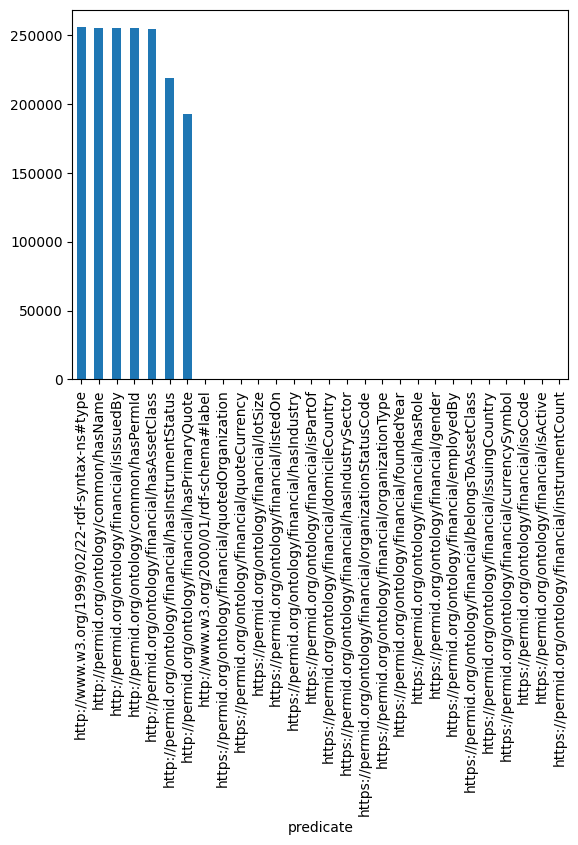

In [18]:
print("\nTop predicates:")
print(predicate_counts.head(30))

# Distribution plot
plt.figure()
predicate_counts.plot(kind="bar")
plt.show()

# =========================

# END

# =========================
